## Import Libraries

In [27]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

## Feature Engineering

In [28]:
df = pd.read_csv ("../data/Predictive Maintenance Dataset.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [29]:
df["Temperature difference [K]"] = (
    df["Process temperature [K]"] - df["Air temperature [K]"]
)

df["Power proxy [W]"] = (
    df["Torque [Nm]"] * df["Rotational speed [rpm]"] * 2 * np.pi / 60
)

df["Tool wear level"] = pd.cut(
    df["Tool wear [min]"],
    bins=[-1, 80, 160, 260],
    labels=["Low", "Medium", "High"]
)

## Modeling dataframe

In [30]:
model_df = df.copy()

model_df = model_df.drop(
    columns=[
        "UDI",
        "Product ID",
        "TWF",
        "HDF",
        "PWF",
        "OSF",
        "RNF"
    ]
)

model_df = pd.get_dummies(
    model_df,
    columns=["Type", "Tool wear level"],
    drop_first=True,
    dtype=int
)

X = model_df.drop(columns=["Machine failure"])
y = model_df["Machine failure"]

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())
display(y.value_counts(normalize=True) * 100)

X shape: (10000, 11)
y shape: (10000,)


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temperature difference [K],Power proxy [W],Type_L,Type_M,Tool wear level_Medium,Tool wear level_High
0,298.1,308.6,1551,42.8,0,10.5,6951.590560,0,1,0,0
1,298.2,308.7,1408,46.3,3,10.5,6826.722724,1,0,0,0
2,298.1,308.5,1498,49.4,5,10.4,7749.387543,1,0,0,0
3,298.2,308.6,1433,39.5,7,10.4,5927.504659,1,0,0,0
4,298.2,308.7,1408,40.0,9,10.5,5897.816608,1,0,0,0


Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

## Train/Test Split

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("Training target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("Testing target distribution:")
print(y_test.value_counts(normalize=True) * 100)

X_train shape: (8000, 11)
X_test shape: (2000, 11)
Training target distribution:
Machine failure
0    96.6125
1     3.3875
Name: proportion, dtype: float64
Testing target distribution:
Machine failure
0    96.6
1     3.4
Name: proportion, dtype: float64


## Standardization

In [32]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Logistic Regression Baseline

In [33]:
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train_scaled, y_train)
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

## Model Evaluation

In [34]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC-AUC:", roc_auc)
print(classification_report(y_test, y_pred))

Accuracy: 0.9695
Precision: 0.6521739130434783
Recall: 0.22058823529411764
F1 Score: 0.32967032967032966
ROC-AUC: 0.926249847765193
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1932
           1       0.65      0.22      0.33        68

    accuracy                           0.97      2000
   macro avg       0.81      0.61      0.66      2000
weighted avg       0.96      0.97      0.96      2000



## Confusion Matrix

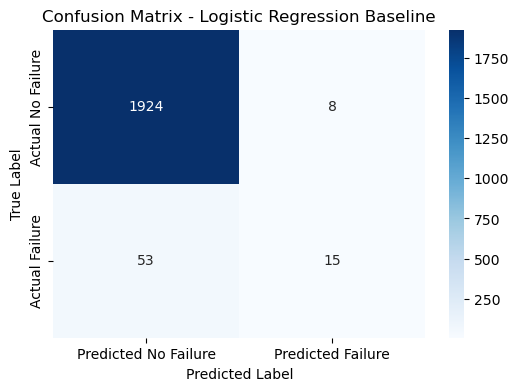

In [35]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted No Failure", "Predicted Failure"],
    yticklabels=["Actual No Failure", "Actual Failure"]
)

plt.title("Confusion Matrix - Logistic Regression Baseline")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

## Class Weight

In [39]:
log_reg_balanced = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

log_reg_balanced.fit(X_train_scaled, y_train)

y_pred_balanced = log_reg_balanced.predict(X_test_scaled)
y_pred_proba_balanced = log_reg_balanced.predict_proba(X_test_scaled)[:, 1]
accuracy_balanced = accuracy_score(y_test, y_pred_balanced)
precision_balanced = precision_score(y_test, y_pred_balanced)
recall_balanced = recall_score(y_test, y_pred_balanced)
f1_balanced = f1_score(y_test, y_pred_balanced)
roc_auc_balanced = roc_auc_score(y_test, y_pred_proba_balanced)

print("Accuracy:", accuracy_balanced)
print("Precision:", precision_balanced)
print("Recall:", recall_balanced)
print("F1 Score:", f1_balanced)
print("ROC-AUC:", roc_auc_balanced)

print(classification_report(y_test, y_pred_balanced))

Accuracy: 0.8555
Precision: 0.17595307917888564
Recall: 0.8823529411764706
F1 Score: 0.293398533007335
ROC-AUC: 0.9321261113140908
              precision    recall  f1-score   support

           0       1.00      0.85      0.92      1932
           1       0.18      0.88      0.29        68

    accuracy                           0.86      2000
   macro avg       0.59      0.87      0.61      2000
weighted avg       0.97      0.86      0.90      2000



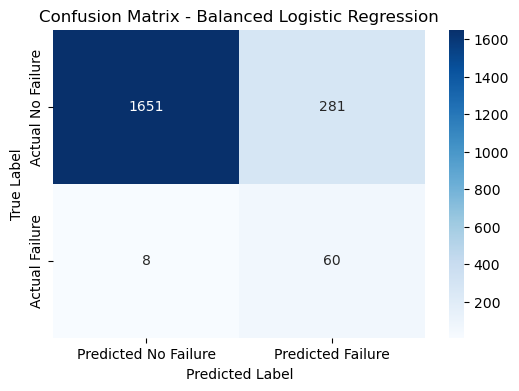

In [37]:
cm_balanced = confusion_matrix(y_test, y_pred_balanced)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_balanced,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted No Failure", "Predicted Failure"],
    yticklabels=["Actual No Failure", "Actual Failure"]
)

plt.title("Confusion Matrix - Balanced Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

## Model Comparison Table

In [40]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression"
    ],
    "Accuracy": [
        accuracy,
        accuracy_balanced
    ],
    "Precision": [
        precision,
        precision_balanced
    ],
    "Recall": [
        recall,
        recall_balanced
    ],
    "F1 Score": [
        f1,
        f1_balanced
    ],
    "ROC-AUC": [
        roc_auc,
        roc_auc_balanced
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9695,0.652174,0.220588,0.329670,0.926250
1,Balanced Logistic Regression,0.8555,0.175953,0.882353,0.293399,0.932126


## Initial Modeling Findings

Two logistic regression models were trained as baseline models for binary machine failure prediction: a standard logistic regression model and a balanced logistic regression model.

The standard logistic regression model achieved high overall accuracy, but this result is misleading because the dataset is highly imbalanced. Only about 3.39% of the records represent machine failure cases. The model achieved a failure-class precision of approximately 0.65, but its failure-class recall was only about 0.22. This means the model was relatively conservative when predicting failures. When it predicted a failure, it was often correct, but it missed many actual failure cases.

The balanced logistic regression model used `class_weight="balanced"` to give more importance to the minority failure class during training. This significantly increased failure-class recall to approximately 0.88, meaning the model detected most actual failure cases. However, failure-class precision dropped to approximately 0.18, meaning the model produced many false alarms.

This result reveals an important predictive maintenance trade-off. A conservative model reduces false alarms but may miss real machine failures, while a more sensitive model detects more failures but may create unnecessary maintenance alerts. In a manufacturing environment, missing a real failure can lead to unplanned downtime, production delays, and higher maintenance costs. However, too many false alarms can also reduce trust in the system and increase unnecessary inspection workload.

Therefore, accuracy alone is not an appropriate evaluation metric for this project. Precision, recall, F1-score, confusion matrix, and ROC-AUC provide a more complete view of model performance. For predictive maintenance, recall is especially important because the cost of missing an actual failure may be high.

The next step is to compare these logistic regression baselines with tree-based models such as Random Forest. Random Forest may capture nonlinear relationships between operating variables more effectively, especially interactions among torque, rotational speed, tool wear, and temperature-related features. Later, threshold tuning and precision-recall analysis can also be used to better control the trade-off between false alarms and missed failures.

## Random Forest Model

In [42]:
from sklearn.ensemble import RandomForestClassifier

In [43]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

In [44]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print("Accuracy:", accuracy_rf)
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1 Score:", f1_rf)
print("ROC-AUC:", roc_auc_rf)

print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9905
Precision: 0.9454545454545454
Recall: 0.7647058823529411
F1 Score: 0.8455284552845529
ROC-AUC: 0.9659450736816466
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1932
           1       0.95      0.76      0.85        68

    accuracy                           0.99      2000
   macro avg       0.97      0.88      0.92      2000
weighted avg       0.99      0.99      0.99      2000



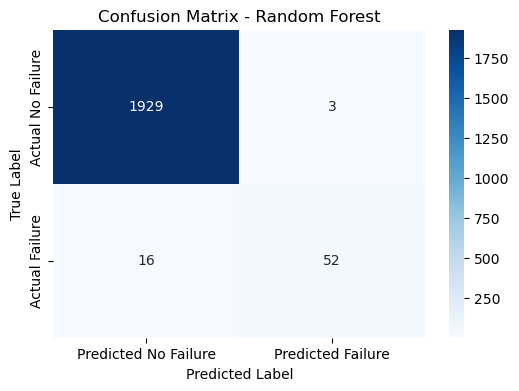

In [45]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted No Failure", "Predicted Failure"],
    yticklabels=["Actual No Failure", "Actual Failure"]
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [46]:
rf_balanced = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_balanced.fit(X_train, y_train)

y_pred_rf_balanced = rf_balanced.predict(X_test)
y_pred_proba_rf_balanced = rf_balanced.predict_proba(X_test)[:, 1]

In [47]:
accuracy_rf_balanced = accuracy_score(y_test, y_pred_rf_balanced)
precision_rf_balanced = precision_score(y_test, y_pred_rf_balanced)
recall_rf_balanced = recall_score(y_test, y_pred_rf_balanced)
f1_rf_balanced = f1_score(y_test, y_pred_rf_balanced)
roc_auc_rf_balanced = roc_auc_score(y_test, y_pred_proba_rf_balanced)

print("Accuracy:", accuracy_rf_balanced)
print("Precision:", precision_rf_balanced)
print("Recall:", recall_rf_balanced)
print("F1 Score:", f1_rf_balanced)
print("ROC-AUC:", roc_auc_rf_balanced)

print(classification_report(y_test, y_pred_rf_balanced))

Accuracy: 0.988
Precision: 0.94
Recall: 0.6911764705882353
F1 Score: 0.7966101694915254
ROC-AUC: 0.9717604433077579
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.94      0.69      0.80        68

    accuracy                           0.99      2000
   macro avg       0.96      0.84      0.90      2000
weighted avg       0.99      0.99      0.99      2000



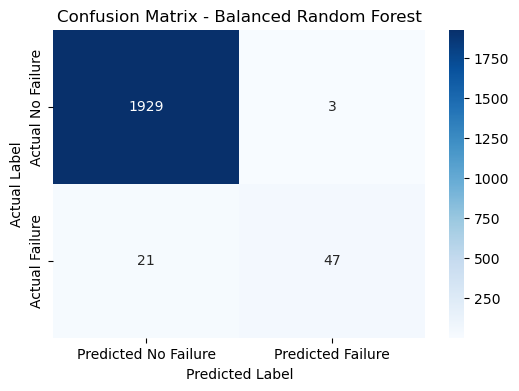

In [48]:
cm_rf_balanced = confusion_matrix(y_test, y_pred_rf_balanced)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_rf_balanced,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted No Failure", "Predicted Failure"],
    yticklabels=["Actual No Failure", "Actual Failure"]
)

plt.title("Confusion Matrix - Balanced Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [49]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression",
        "Random Forest",
        "Balanced Random Forest"
    ],
    "Accuracy": [
        accuracy,
        accuracy_balanced,
        accuracy_rf,
        accuracy_rf_balanced
    ],
    "Precision": [
        precision,
        precision_balanced,
        precision_rf,
        precision_rf_balanced
    ],
    "Recall": [
        recall,
        recall_balanced,
        recall_rf,
        recall_rf_balanced
    ],
    "F1 Score": [
        f1,
        f1_balanced,
        f1_rf,
        f1_rf_balanced
    ],
    "ROC-AUC": [
        roc_auc,
        roc_auc_balanced,
        roc_auc_rf,
        roc_auc_rf_balanced
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9695,0.652174,0.220588,0.329670,0.926250
1,Balanced Logistic Regression,0.8555,0.175953,0.882353,0.293399,0.932126
2,Random Forest,0.9905,0.945455,0.764706,0.845528,0.965945
3,Balanced Random Forest,0.9880,0.940000,0.691176,0.796610,0.971760


## Random Forest Modeling Findings

Random Forest models were added to compare nonlinear tree-based classifiers with the logistic regression baselines. The results show a clear performance improvement after moving from linear models to tree-based models.

The standard logistic regression model achieved high accuracy, but its failure-class recall was only 0.221. This means it missed many actual failure cases. The balanced logistic regression model improved recall to 0.882, but precision dropped sharply to 0.176, indicating many false alarms.

The standard Random Forest model produced the strongest overall performance. It achieved an accuracy of 0.991, precision of 0.945, recall of 0.765, F1-score of 0.846, and ROC-AUC of 0.966. Compared with logistic regression, Random Forest provided a much better balance between detecting actual failures and avoiding false alarms.

The balanced Random Forest model also performed well, with accuracy of 0.988, precision of 0.940, recall of 0.691, F1-score of 0.797, and ROC-AUC of 0.972. Although it had the highest ROC-AUC score among all models, its recall and F1-score were lower than the standard Random Forest model.

Based on these results, the standard Random Forest model is currently the best candidate model for PredictWise. It provides the strongest balance across precision, recall, and F1-score. This suggests that machine failure prediction in this dataset depends on nonlinear relationships and feature interactions among variables such as torque, rotational speed, tool wear, power proxy, and temperature-related features.

The next step is to perform threshold tuning on the Random Forest model. Since predictive maintenance requires balancing missed failures and false alarms, adjusting the classification threshold may further improve the practical usefulness of the model.

## Threshold Tuning

In [50]:
y_scores = y_pred_proba_rf

In [51]:
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_scores >= threshold).astype(int)
    
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred_threshold),
        "Recall": recall_score(y_test, y_pred_threshold),
        "F1 Score": f1_score(y_test, y_pred_threshold)
    })

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df

,Threshold,Precision,Recall,F1 Score
0,0.2,0.721519,0.838235,0.775510
1,0.3,0.826087,0.838235,0.832117
2,0.4,0.918033,0.823529,0.868217
3,0.5,0.945455,0.764706,0.845528
4,0.6,0.960000,0.705882,0.813559
5,0.7,1.000000,0.617647,0.763636


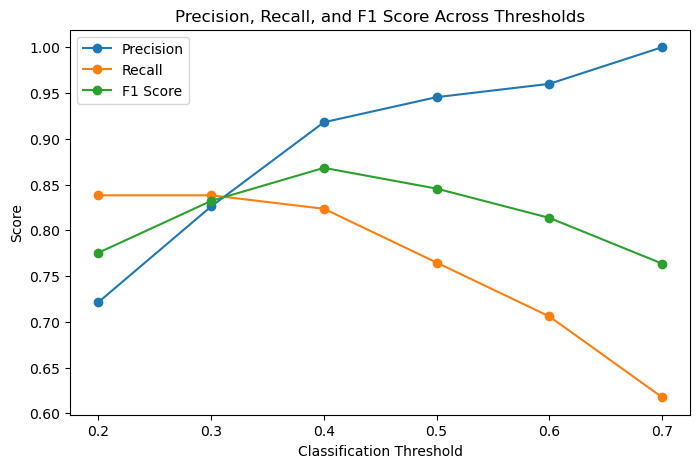

In [52]:
plt.figure(figsize=(8, 5))

plt.plot(threshold_results_df["Threshold"], threshold_results_df["Precision"], marker="o", label="Precision")
plt.plot(threshold_results_df["Threshold"], threshold_results_df["Recall"], marker="o", label="Recall")
plt.plot(threshold_results_df["Threshold"], threshold_results_df["F1 Score"], marker="o", label="F1 Score")

plt.title("Precision, Recall, and F1 Score Across Thresholds")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.legend()

plt.show()

In [53]:
from sklearn.metrics import precision_recall_curve, average_precision_score

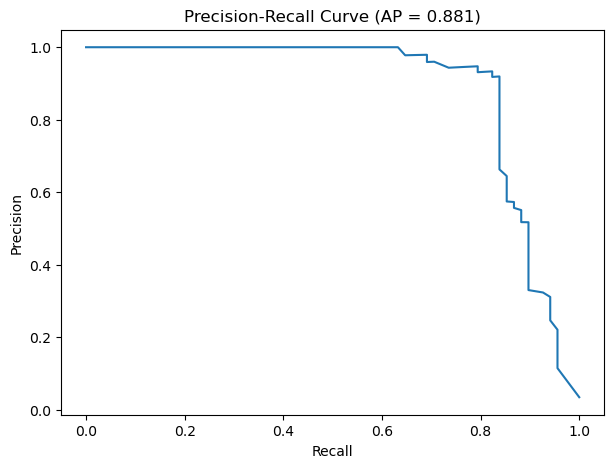

In [54]:
precision_curve, recall_curve, thresholds_curve = precision_recall_curve(y_test, y_scores)
avg_precision = average_precision_score(y_test, y_scores)

plt.figure(figsize=(7, 5))

plt.plot(recall_curve, precision_curve)

plt.title(f"Precision-Recall Curve (AP = {avg_precision:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.show()

## Day 5 Findings: Threshold Tuning and Precision-Recall Analysis

Threshold tuning was performed on the Random Forest model to better understand the trade-off between precision, recall, and F1-score. In the default classification setting, a machine is predicted as a failure when the predicted failure probability is greater than or equal to 0.5. However, for predictive maintenance, this default threshold may not always be the best choice because machine failures are rare but costly.

The threshold tuning results show a clear trade-off. As the classification threshold increases from 0.2 to 0.7, precision increases while recall decreases. This means that higher thresholds make the model more conservative: when the model predicts a failure, it is more likely to be correct, but it also misses more actual failures. Lower thresholds make the model more sensitive: it detects more actual failures, but it also creates more false alarms.

In this analysis, the F1-score reaches its highest value around a threshold of 0.4. At this point, the model provides the best balance between precision and recall among the tested thresholds. This suggests that a threshold near 0.4 may be more practical than the default 0.5 threshold if the goal is to balance failure detection with false alarm control.

The precision-recall curve also supports the strength of the Random Forest model. The Average Precision score is 0.881, indicating that the model maintains strong precision-recall performance across a range of thresholds. Since the dataset is highly imbalanced, this precision-recall analysis is more informative than accuracy alone.

From an engineering perspective, the threshold should be selected based on the maintenance strategy. If the factory wants to minimize missed failures and avoid unplanned downtime, a lower threshold such as 0.3 or 0.4 may be preferred. If the factory wants to reduce unnecessary inspections and false alarms, a higher threshold such as 0.5 or 0.6 may be more appropriate.

For PredictWise, a threshold of approximately 0.4 is currently the strongest candidate because it provides the best F1-score and balances the cost of missed failures against the cost of false alarms.

## Model Interpretation

In [55]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
6,Power proxy [W],0.249952
3,Torque [Nm],0.179552
2,Rotational speed [rpm],0.177543
5,Temperature difference [K],0.140498
4,Tool wear [min],0.117093
0,Air temperature [K],0.052778
1,Process temperature [K],0.045961
10,Tool wear level_High,0.013364
7,Type_L,0.012130
8,Type_M,0.008472


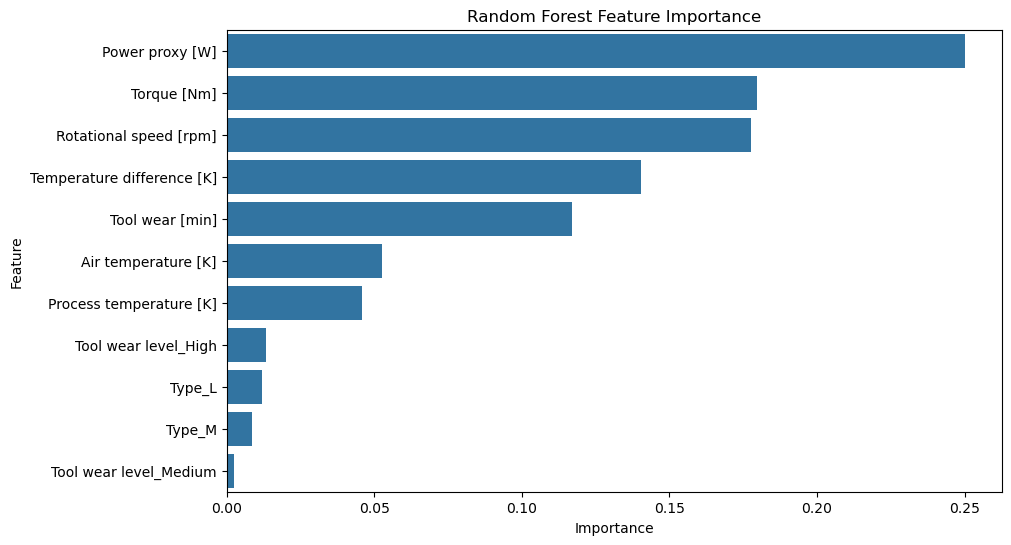

In [56]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## Model Interpretation Findings

Random Forest feature importance was used to interpret which variables contributed most to machine failure prediction.

The most important feature was `Power proxy [W]`, with an importance score of approximately 0.250. This engineered feature combines torque and rotational speed to represent machine power demand. Its high importance suggests that the interaction between load and speed is highly relevant to failure prediction. This supports the engineering assumption that machine failure risk is not determined by a single operating variable, but by combined operating intensity.

The next most important features were `Torque [Nm]` and `Rotational speed [rpm]`, with importance scores of approximately 0.180 and 0.178. These variables describe the mechanical operating condition of the machine. High torque can indicate heavier load, while rotational speed reflects how fast the machine is operating. Their strong importance suggests that mechanical stress and operating regime are major contributors to failure risk.

`Temperature difference [K]` was also an important feature, with an importance score of approximately 0.140. This engineered feature captures the gap between process temperature and air temperature. Its relatively high ranking suggests that thermal load and heat buildup may be meaningful indicators of machine failure risk.

`Tool wear [min]` ranked fifth, with an importance score of approximately 0.117. This indicates that accumulated tool usage is also relevant to failure prediction, although it is less influential than the power, torque, speed, and temperature-related features in this model.

The original temperature variables, `Air temperature [K]` and `Process temperature [K]`, had lower importance scores than `Temperature difference [K]`. This suggests that the engineered temperature difference feature may capture thermal behavior more effectively than the raw temperature values alone.

The categorical variables, including `Type_L`, `Type_M`, `Tool wear level_High`, and `Tool wear level_Medium`, had relatively low importance scores. This suggests that product type and binned tool wear categories contribute less to the Random Forest model than continuous operating variables.

Overall, the feature importance results show that the Random Forest model relies most heavily on mechanical load, rotational behavior, power demand, thermal difference, and tool wear. This aligns well with the engineering logic behind predictive maintenance: machine failure is more strongly associated with operating intensity and accumulated mechanical stress than with product category alone.

These findings also show that feature engineering improved the interpretability of the model. Both `Power proxy [W]` and `Temperature difference [K]` ranked among the most important features, indicating that engineered features helped translate raw sensor data into more meaningful indicators of machine condition.

## Save Best Model

Save the fitted standard Random Forest, its ordered feature schema, and the recommended decision threshold for the Streamlit app.

In [ ]:
from pathlib import Path
import joblib

model_dir = Path("../models")
model_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(rf, model_dir / "random_forest_model.pkl")
joblib.dump(X_train.columns.tolist(), model_dir / "feature_columns.pkl")
joblib.dump(0.4, model_dir / "recommended_threshold.pkl")

print(f"Saved model artifacts to {model_dir.resolve()}")